# Detect health of the plant

In [ ]:
import torch
import torchvision
# Get regular imports 
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular.going_modular.engine import train_test_step
from going_modular.going_modular.data_import import get_data
import os
import pandas as pd

In [2]:
dataset_dir = "data/plant"

In [4]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


/tmp/ipykernel_275131/1573505709.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plant_df.plant, rotation=90)


Text(0.5, 1.0, 'Dataset balance')

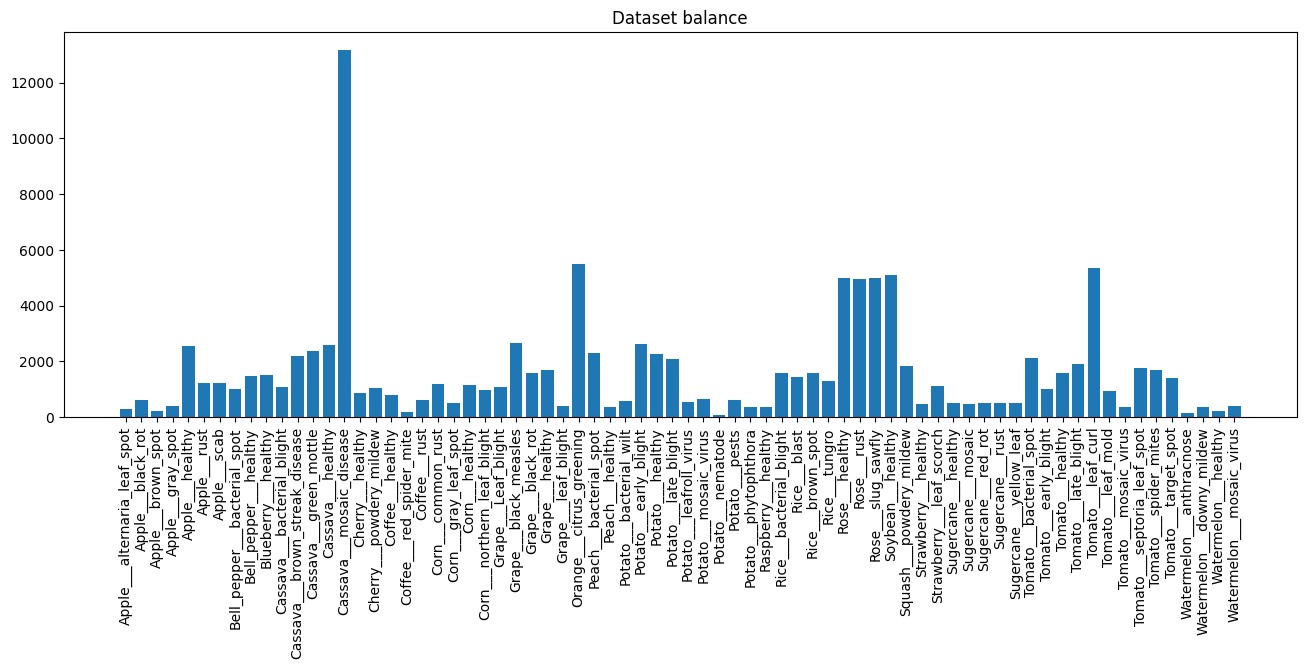

In [34]:
# Check if the dataset is balanced
plant_dict = {}
for dir in os.listdir(dataset_dir):
    plant_dict[dir] = len(os.listdir(os.path.join(dataset_dir, dir)))
plant_df = pd.DataFrame(plant_dict.items(), columns=["plant", "num"]).sort_values(by="plant")
fig = plt.figure(figsize=(35, 5))
ax = fig.add_subplot(1, 2, 1)
ax.bar(plant_df.plant, plant_df.num)
ax.set_xticklabels(plant_df.plant, rotation=90)
ax.set_title("Dataset balance")

In [35]:
plant_df

,plant,num
34,Apple___alternaria_leaf_spot,278
49,Apple___black_rot,621
40,Apple___brown_spot,215
14,Apple___gray_spot,395
38,Apple___healthy,2570
...,...,...
55,Tomato___target_spot,1404
54,Watermelon___anthracnose,155
16,Watermelon___downy_mildew,380
31,Watermelon___healthy,205


In [39]:
import torch
import torchvision
from torch import nn
from typing import Tuple

def create_vitb16_model(num_classes: int = 3,
                        seed: int = 42) -> Tuple[nn.Module, torchvision.transforms.Compose]:
    """
    Create a ViT-B/16 feature extractor model and transforms

    Args:
        num_classes (int, optional): number of classes. Defaults to 3.
        seed (int, optional): random seed. Defaults to 42.

    Returns:
        model (nn.Module): ViT-B/16 feature extractor model, 
        transforms (torchvision.transforms.Compose): ViT-B/16 images transforms
    """
    # Get the model weights
    weights = torchvision.models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
    # Get automatic transforms from pretrained ViT weights
    transforms = weights.transforms()
    # Get the model architecture with pretrained weights
    model = torchvision.models.vit_b_16(weights=weights)
    # Freeze the feature extractor
    for param in model.parameters():
        param.requires_grad = False
    # Get the last layer input
    for module in reversed(list(model.modules())):
        if isinstance(module, nn.Linear):
            in_features = module.in_features
            break     
    # Get its head
    torch.manual_seed(seed)
    model.heads = nn.Linear(in_features=in_features, out_features=num_classes)
    return model, transforms

In [ ]:
vit_b16_model, transforms = create_vitb16_model(num_classes=len(os.listdir(dataset_dir)))

In [43]:
import torchvision.transforms as T
train_transforms = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms
])

In [72]:
import importlib
import going_modular.going_modular.data_setup as data_setup
importlib.reload(data_setup)
from going_modular.going_modular.data_setup import create_dataloaders

In [73]:
train_dataloader, test_dataloader, class_names = create_dataloaders(transform=train_transforms,
                                                                    test_transform=transforms,
                                                                    train_dir=dataset_dir,
                                                                    split_size=0.8)

[INFO] Splitting dataset of length 116147 into splits of size: 92917 (80%), 23230 (19%)
Train data:
Test data:
Classes are not balanced, creating weights for each sample...


In [74]:
from going_modular.going_modular.engine import train_test_step

optimizer = torch.optim.Adam(vit_b16_model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
history = train_test_step(model=vit_b16_model,
                          train_dataloader=train_dataloader,
                          test_dataloader=test_dataloader,
                          loss_fn=loss_fn,
                          optimizer=optimizer,
                          epochs=5,
                          device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
-------
Looked at 0/92917 samples
Looked at 12800/92917 samples
Looked at 25600/92917 samples
Looked at 38400/92917 samples
Looked at 51200/92917 samples
Looked at 64000/92917 samples
Looked at 76800/92917 samples
Looked at 89600/92917 samples
Train loss: 1.367 | Train accuracy: 82.00% | Max train probability: 69.74%
Test loss: 1.297 | Test accuracy: 84.40% | Max test probability: 74.65%
Epoch 1
-------
Looked at 0/92917 samples
Looked at 12800/92917 samples
Looked at 25600/92917 samples
Looked at 38400/92917 samples
Looked at 51200/92917 samples
Looked at 64000/92917 samples
Looked at 76800/92917 samples
Looked at 89600/92917 samples
Train loss: 1.240 | Train accuracy: 86.46% | Max train probability: 75.86%
Test loss: 1.265 | Test accuracy: 85.68% | Max test probability: 74.84%
Epoch 2
-------
Looked at 0/92917 samples
Looked at 12800/92917 samples
Looked at 25600/92917 samples
Looked at 38400/92917 samples
Looked at 51200/92917 samples
Looked at 64000/92917 samples
Looked at 

In [75]:
from going_modular.going_modular.utils import save_model

save_model(model=vit_b16_model,
          target_dir="models",
          model_name="dectection_plant_health_model.pth")

[INFO] Saving model to: models/dectection_plant_health_model.pth
